In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
def fit_func(x,A,x0,alpha):
    return A*(1+(x/x0)**(2*alpha))**(-0.5)

In [5]:
ramp_times_200326 = [4.,16.,64.,128.]
ramp_times_200326 = np.array(ramp_times_200326)*1e-3/2.
defect_densities_200326 = [0.061,0.044,0.031,0.017]
defect_densities_200326 = np.array(defect_densities_200326)
error_bars_200326 = [0.003,0.003,0.003,0.002]
error_bars_200326 = np.array(error_bars_200326)

In [6]:
ramp_times_240326 = [1.,2.,8.,32.]
ramp_times_240326 = np.array(ramp_times_240326)*1e-3/2.
defect_densities_240326 = [0.125,0.126,0.062,0.035]
defect_densities_240326 = np.array(defect_densities_240326)
error_bars_240326 = [0.003,0.003,0.003,0.003]
error_bars_240326 = np.array(error_bars_240326)

In [7]:
ramp_times_250326 = [4.0,16.]
ramp_times_250326 = np.array(ramp_times_250326)*1e-3/2.
defect_densities_250326 = [0.096,0.071]
defect_densities_250326 = np.array(defect_densities_250326)
error_bars_250326 = [0.004,0.003]
error_bars_250326 = np.array(error_bars_250326)

In [8]:
ramp_times_310326 = [2.,32.]
ramp_times_310326 = np.array(ramp_times_310326)*1e-3/2.
defect_densities_310326 = [0.121,0.025]
defect_densities_310326 = np.array(defect_densities_310326)
error_bars_310326 = [0.009,0.005]
error_bars_310326 = np.array(error_bars_310326)


In [9]:
ramp_time_all = np.concatenate((ramp_times_200326,ramp_times_240326,ramp_times_250326,ramp_times_310326))
defect_density_all = np.concatenate((defect_densities_200326,defect_densities_240326,defect_densities_250326,defect_densities_310326))
error_bars_all = np.concatenate((error_bars_200326,error_bars_240326,error_bars_250326,error_bars_310326))
print("defect_densities_all:", defect_density_all)

defect_densities_all: [0.061 0.044 0.031 0.017 0.125 0.126 0.062 0.035 0.096 0.071 0.121 0.025]


In [10]:

p0_all = [0.12, 0.003, 0.45]
fit_all = curve_fit(fit_func, ramp_time_all, defect_density_all, p0=p0_all)
print("All fit parameters:", fit_all[0])

All fit parameters: [0.17225175 0.00073146 0.50682137]


/tmp/ipykernel_663639/2397080620.py:2: RuntimeWarning: invalid value encountered in power
  return A*(1+(x/x0)**(2*alpha))**(-0.5)


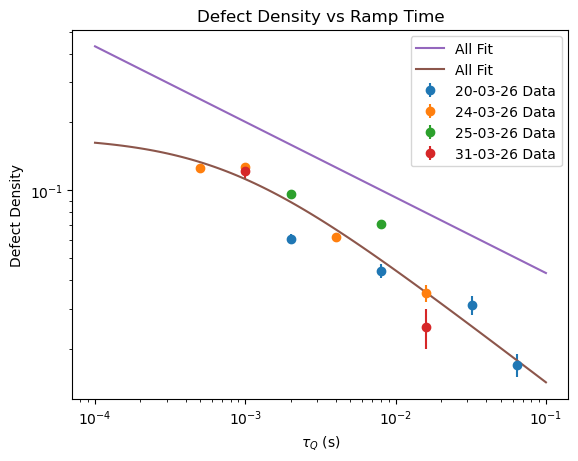

In [14]:
plt.errorbar(ramp_times_200326, defect_densities_200326, yerr=error_bars_200326, fmt='o', label='20-03-26 Data')
plt.errorbar(ramp_times_240326, defect_densities_240326, yerr=error_bars_240326, fmt='o', label='24-03-26 Data')
plt.errorbar(ramp_times_250326, defect_densities_250326, yerr=error_bars_250326, fmt='o', label='25-03-26 Data')
plt.errorbar(ramp_times_310326, defect_densities_310326, yerr=error_bars_310326, fmt='o', label='31-03-26 Data')
x_fit = np.logspace(-4, -1, 100)
plt.plot(np.linspace(1e-4, 1e-1, 100), 0.02*np.linspace(1e-4, 1e-1, 100)**(-1/3.), label='All Fit')
# plot initial guess
#plt.plot(x_fit, fit_func(x_fit, *p0_all), label='Initial Guess', linestyle='--')
plt.plot(x_fit, fit_func(x_fit, *fit_all[0]), label='All Fit')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\tau_Q$ (s)')
plt.ylabel('Defect Density')
plt.title('Defect Density vs Ramp Time')
plt.legend()
plt.show()

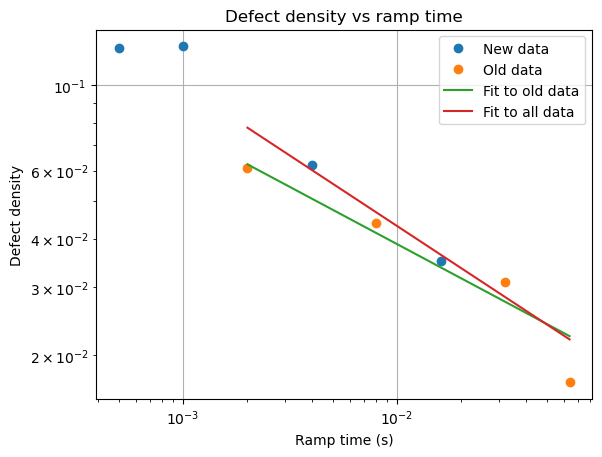

In [51]:
plt.plot(ramp_times, defect_densities, 'o', label='New data')
plt.plot(ramp_times_old, defect_densities_old, 'o', label='Old data')
# plot initial guess fit
x_fit = np.logspace(np.log10(min(ramp_times_old)), np.log10(max(ramp_times_old)), 100)
plt.plot(x_fit, fit_func(x_fit, *fit_old[0]), '-', label='Fit to old data')

plt.plot(x_fit, fit_func(x_fit, *fit_all[0]), '-', label='Fit to all data')
plt.xscale('log')
plt.xlabel('Ramp time (s)')
plt.ylabel('Defect density')
plt.title('Defect density vs ramp time')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()